# Introduction to Scikit-learn

This notebook demonstrates some of the most beautiful functions of the beautiful Scikit-learn library.

What we'll cover.

0.  An end-to-end Scikit-learn workflow.
1.  Getting the Data ready.
2.  Choose the right estimator/algorithm/model for our problems.
3.  Fit the model algorithm/model and use it to make predictions on our data.
4.  Evaluating a model.
5.  Improve a model.
6.  Save and load a trained model.
7.  Putting it all together!

## 0.  An end-to-end Scikit-learn workflow. 

---
## 1. Get the data ready

### Standard Imports

In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [64]:
heart_disease = pd.read_csv("data/heart-disease.csv")
heart_disease

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


In [65]:
#  Create X (features matrix)
X = heart_disease.drop("target", axis=1)

#  Create y (labels)
y = heart_disease["target"]

### to filter warnings
- default/ignore

In [66]:
# import warnings
# warnings.filterwarnings("default")

---
## 2. Choose the right model and hyperparameters.

### RandomForestClassifier
- A random forest classifier.
- A random forest is a meta estimator that fits a number of decision tree
classifiers on various sub-samples of the dataset and uses averaging to
improve the predictive accuracy and control over-fitting.

### get_params()
- Get parameters for this estimator.

In [67]:
from sklearn.ensemble import RandomForestClassifier
clf = RandomForestClassifier(n_estimators=100)

# We'll keep the default hyperparameters
clf.get_params()

{'bootstrap': True,
 'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': 'sqrt',
 'max_leaf_nodes': None,
 'max_samples': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'n_estimators': 100,
 'n_jobs': None,
 'oob_score': False,
 'random_state': None,
 'verbose': 0,
 'warm_start': False}

---
### 3. Fit the model to the training data and use it to make predictions.

### train_test_split
- Split arrays or matrices into random train and test subsets.

### fit
- Build a forest of trees from the training set (X, y).

In [68]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [69]:
clf.fit(X_train , y_train);

### Make Predictions.

In [70]:
# y_label = clf.predict(np.array([0, 2, 3, 4]));

In [71]:
y_preds = clf.predict(X_test)
y_preds

array([0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0,
       1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0,
       1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0])

In [72]:
y_test

42     1
291    0
15     1
51     1
265    0
      ..
18     1
247    0
126    1
131    1
176    0
Name: target, Length: 61, dtype: int64

## 4. Evaluate the model on the training data and test data.

### score
- Return the mean accuracy on the provided data and labels.


In [73]:
clf.score(X_train, y_train)

1.0

In [74]:
clf.score(X_test, y_test)

0.7704918032786885

### classification_report
- Build a text report showing the main classification metrics.
### confusion_matrix
- Compute confusion matrix to evaluate the accuracy of a classification.
### accuracy_score
- Accuracy classification score, In multilabel classification, this function computes subset accuracy:
the set of labels predicted for a sample must *exactly* match the
corresponding set of labels in y_true.

In [75]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print(classification_report(y_test, y_preds)) 

              precision    recall  f1-score   support

           0       0.63      0.81      0.71        21
           1       0.88      0.75      0.81        40

    accuracy                           0.77        61
   macro avg       0.76      0.78      0.76        61
weighted avg       0.80      0.77      0.78        61



In [76]:
confusion_matrix(y_test, y_preds)

array([[17,  4],
       [10, 30]])

In [77]:
accuracy_score(y_test, y_preds)

0.7704918032786885

## 5. Improve a model.

### Try different amount of n_estimators

In [78]:
np.random.seed(42)
for i in range(10, 100, 10):
    print(f"Trying model with {i} estimators...")
    clf = RandomForestClassifier(n_estimators=i).fit(X_train, y_train)
    print(f"Model accuracy on test set: {clf.score(X_test, y_test) * 100:.2f}%")

Trying model with 10 estimators...
Model accuracy on test set: 80.33%
Trying model with 20 estimators...
Model accuracy on test set: 80.33%
Trying model with 30 estimators...
Model accuracy on test set: 78.69%
Trying model with 40 estimators...
Model accuracy on test set: 78.69%
Trying model with 50 estimators...
Model accuracy on test set: 77.05%
Trying model with 60 estimators...
Model accuracy on test set: 77.05%
Trying model with 70 estimators...
Model accuracy on test set: 80.33%
Trying model with 80 estimators...
Model accuracy on test set: 81.97%
Trying model with 90 estimators...
Model accuracy on test set: 80.33%


## 6. Save a Model and Load it.

In [79]:
import pickle

with open("random_forest_model_1.pkl", "wb") as f:
    pickle.dump(clf, f)

In [80]:
loaded_model = pickle.load(open("random_forest_model_1.pkl", "rb"))
loaded_model.score(X_test, y_test)

0.8032786885245902

---
### Let's get start one by one.
# 1. Getting our data ready to be used with Machine Learning.
 Three main things we have to do.
   1. Split the data into features and labels (usually `X` & `y`)
   2. Filling (also called imputing) or disregarding missing values
   3. Converting non-numercial values to numerical-values (also called feature encoding)
    

In [81]:
heart_disease.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [82]:
X = heart_disease.drop("target", axis=1)
X.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2


In [83]:
y = heart_disease["target"]
y.head()

0    1
1    1
2    1
3    1
4    1
Name: target, dtype: int64

### Split the data into training and testing set.

In [84]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y, 
                                                    test_size=0.2)

In [85]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((242, 13), (61, 13), (242,), (61,))

### 1.1 Make sure it's all numerical

In [86]:
car_sales = pd.read_csv("data/car-sales-extended.csv")
car_sales.head()

,Make,Colour,Odometer (KM),Doors,Price
0,Honda,White,35431,4,15323
1,BMW,Blue,192714,5,19943
2,Honda,White,84714,4,28343
3,Toyota,White,154365,4,13434
4,Nissan,Blue,181577,3,14043


In [87]:
len(car_sales)

1000

In [88]:
car_sales.dtypes

Make             object
Colour           object
Odometer (KM)     int64
Doors             int64
Price             int64
dtype: object

### Split into X/y

In [89]:
X = car_sales.drop(["Price"], axis=1)
y = car_sales["Price"]

### Spliting into training and testing data set.

In [90]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

### Build Machine Learning Model

In [91]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
model.fit(X_train, y_train)
model.score(X_test, y_test)

ValueError: could not convert string to float: 'Toyota'

### 1.1 Turn the categories into numbers.

In [92]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_features = ["Make", "Colour", "Doors"]
one_hot = OneHotEncoder()
transformer = ColumnTransformer([("one_hot", one_hot, categorical_features)],
                               remainder="passthrough")

transformed_X = transformer.fit_transform(X)
transformed_X

array([[0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 3.54310e+04],
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        1.00000e+00, 1.92714e+05],
       [0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 8.47140e+04],
       ...,
       [0.00000e+00, 0.00000e+00, 1.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 6.66040e+04],
       [0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 2.15883e+05],
       [0.00000e+00, 0.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        0.00000e+00, 2.48360e+05]], shape=(1000, 13))

### One more way to do

In [93]:
dummies = pd.get_dummies(car_sales[["Make", "Colour", "Doors"]])
dummies

,Doors,Make_BMW,Make_Honda,Make_Nissan,Make_Toyota,Colour_Black,Colour_Blue,Colour_Green,Colour_Red,Colour_White
0,4,False,True,False,False,False,False,False,False,True
1,5,True,False,False,False,False,True,False,False,False
2,4,False,True,False,False,False,False,False,False,True
3,4,False,False,False,True,False,False,False,False,True
4,3,False,False,True,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...
995,4,False,False,False,True,True,False,False,False,False
996,3,False,False,True,False,False,False,False,False,True
997,4,False,False,True,False,False,True,False,False,False
998,4,False,True,False,False,False,False,False,False,True


### Let's refit our Model.

In [94]:
np.random.seed(42)
X_train, X_test, y_train, y_test = train_test_split(transformed_X, y, test_size=0.2)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [95]:
model.score(transformed_X, y)

0.7520692454946696

---
### 1.2 What if there were missing values ?

1. Fill them with some value (also known as imputation).
2. Remove the samples with missing data altogether.

In [96]:
# import car sales missing data
car_sales_missing_data = pd.read_csv("data/car-sales-extended-missing-data.csv")
car_sales_missing_data.head()

,Make,Colour,Odometer (KM),Doors,Price
0,Honda,White,35431.0,4.0,15323.0
1,BMW,Blue,192714.0,5.0,19943.0
2,Honda,White,84714.0,4.0,28343.0
3,Toyota,White,154365.0,4.0,13434.0
4,Nissan,Blue,181577.0,3.0,14043.0


In [97]:
car_sales_missing_data.isna().sum()

Make             49
Colour           50
Odometer (KM)    50
Doors            50
Price            50
dtype: int64

###  Create X & y


In [98]:
X = car_sales_missing_data.drop("Price", axis=1)
y = car_sales_missing_data["Price"]

In [99]:
# Convert data To Numbers
# Turn the categories into numbers.
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_features = ["Make", "Colour", "Doors"]
one_hot = OneHotEncoder()
transformer = ColumnTransformer([("one_hot", one_hot, categorical_features)],
                               remainder="passthrough")

transformed_X = transformer.fit_transform(X)
transformed_X

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 4000 stored elements and shape (1000, 16)>

### Option 1 : Fill missing data with Pandas.

In [100]:
# Fill the "Make" Cloumn
# car_sales_missing_data["Make"].fillna("missing", inplace=True)
car_sales_missing_data.fillna({"Make": "missing"}, inplace=True)

# Fill the "Colour" Column
# car_sales_missing_data["Colour"].fillna("missing", inplace=True)
car_sales_missing_data.fillna({"Colour": "missing"}, inplace=True)

# Fill the "Odometer (KM)" Column
# car_sales_missing_data["Odometer (KM)"].fillna(car_sales_missing_data["Odometer (KM)"].mean(), inplace=True)
car_sales_missing_data.fillna({"Odometer (KM)": car_sales_missing_data["Odometer (KM)"].mean()}, inplace=True)

# Fill the "Doors" Column
car_sales_missing_data.fillna({"Doors": 4}, inplace=True)


In [101]:
# Check our DataFrame again
car_sales_missing_data.isna().sum()

Make              0
Colour            0
Odometer (KM)     0
Doors             0
Price            50
dtype: int64

In [102]:
#  Remove row with missing "Price" values
car_sales_missing_data.dropna(inplace=True)

In [103]:
car_sales_missing_data.isna().sum()

Make             0
Colour           0
Odometer (KM)    0
Doors            0
Price            0
dtype: int64

In [104]:
len(car_sales_missing_data)

950

In [105]:
X = car_sales_missing_data.drop(["Price"], axis=1)
y = car_sales_missing_data["Price"]

### Convert data To Numbers
### Turn the categories into numbers.

In [106]:
# Convert data To Numbers
# Turn the categories into numbers.
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_features = ["Make", "Colour", "Doors"]
one_hot = OneHotEncoder()
transformer = ColumnTransformer([("one_hot", one_hot, categorical_features)],
                               remainder="passthrough")

transformed_X = transformer.fit_transform(car_sales_missing_data)
transformed_X

array([[0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        3.54310e+04, 1.53230e+04],
       [1.00000e+00, 0.00000e+00, 0.00000e+00, ..., 1.00000e+00,
        1.92714e+05, 1.99430e+04],
       [0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        8.47140e+04, 2.83430e+04],
       ...,
       [0.00000e+00, 0.00000e+00, 1.00000e+00, ..., 0.00000e+00,
        6.66040e+04, 3.15700e+04],
       [0.00000e+00, 1.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        2.15883e+05, 4.00100e+03],
       [0.00000e+00, 0.00000e+00, 0.00000e+00, ..., 0.00000e+00,
        2.48360e+05, 1.27320e+04]], shape=(950, 16))

### Option 2 : Fill missing data with Scikit-learn.

In [107]:
car_sales_missing = pd.read_csv("data/car-sales-extended-missing-data.csv")
car_sales_missing.head()

,Make,Colour,Odometer (KM),Doors,Price
0,Honda,White,35431.0,4.0,15323.0
1,BMW,Blue,192714.0,5.0,19943.0
2,Honda,White,84714.0,4.0,28343.0
3,Toyota,White,154365.0,4.0,13434.0
4,Nissan,Blue,181577.0,3.0,14043.0


In [108]:
car_sales_missing.isna().sum()

Make             49
Colour           50
Odometer (KM)    50
Doors            50
Price            50
dtype: int64

###  Drop the row with no labels.

In [109]:
car_sales_missing.dropna(subset=["Price"], inplace=True) # drop the row where Price value is missing
car_sales_missing.isna().sum()

Make             47
Colour           46
Odometer (KM)    48
Doors            47
Price             0
dtype: int64

### Split into X and y

In [110]:
X = car_sales_missing.drop("Price", axis=1)
y = car_sales_missing["Price"]

### Fill missing values(Imputation) with Scikit-learn.

In [111]:
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer

# Fill categorical values with "missing" & numerical values with mean.
cat_imputer = SimpleImputer(strategy="constant", fill_value="missing")
door_imputer = SimpleImputer(strategy="constant", fill_value=4)
num_imputer = SimpleImputer(strategy="mean")

# Define columns
cat_features = ["Make", "Colour"]
door_features = ["Doors"]
num_features = ["Odometer (KM)"]

# Create an imputer (somethings that fills missing data)
imputer = ColumnTransformer([
    ("cat_imputer", cat_imputer, cat_features),
    ("door_imputer", door_imputer, door_features),
    ("num_imputer", num_imputer, num_features)
])

# Transform the data
filled_X = imputer.fit_transform(X)
filled_X

array([['Honda', 'White', 4.0, 35431.0],
       ['BMW', 'Blue', 5.0, 192714.0],
       ['Honda', 'White', 4.0, 84714.0],
       ...,
       ['Nissan', 'Blue', 4.0, 66604.0],
       ['Honda', 'White', 4.0, 215883.0],
       ['Toyota', 'Blue', 4.0, 248360.0]], shape=(950, 4), dtype=object)

In [112]:
car_sales_filled = pd.DataFrame(filled_X, columns=["Make", "Colour", "Doors", "Odometer (KM)"])
car_sales_filled.head()

,Make,Colour,Doors,Odometer (KM)
0,Honda,White,4.0,35431.0
1,BMW,Blue,5.0,192714.0
2,Honda,White,4.0,84714.0
3,Toyota,White,4.0,154365.0
4,Nissan,Blue,3.0,181577.0


In [113]:
car_sales_filled.isna().sum()

Make             0
Colour           0
Doors            0
Odometer (KM)    0
dtype: int64

In [114]:
# Convert data To Numbers
# Turn the categories into numbers.
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

categorical_features = ["Make", "Colour", "Doors"]
one_hot = OneHotEncoder()
transformer = ColumnTransformer([("one_hot", one_hot, categorical_features)],
                               remainder="passthrough")

transformed_X = transformer.fit_transform(car_sales_filled)
transformed_X

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 3800 stored elements and shape (950, 15)>

### Now we got our data as numbers and filled missing values.
### Let's fit a Model

In [115]:
np.random.seed(42)
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(transformed_X, y, test_size=0.2)

model = RandomForestRegressor()
model.fit(X_train, y_train)
model.score(X_test, y_test)

0.21990196728583944

---
# 2. Choosing the right estimator/algorithm for our problem.

### Scikit-learn uses estimators as another term of machine learning model or algorithm.
* Classification - predicting whether a sample is one thing or another.
* Regression - predicting a number.

Step-1 : Check the ML Mindmap. (https://scikit-learn.org/stable/machine_learning_map.html)

---
## ML MINDMAP FOR MODEL SELECTION
- Condition - Blue Circle
- ML Model - Green Box
![ML Mind Map](data/ml_map.svg)

---
### 2.1 Picking a ML Model for Regression Problem

In [116]:
import pandas as pd
import numpy as np

# Load Boston Housing dataset from original source
url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(url, sep=r"\s+", skiprows=22, header=None)

# Reconstruct feature matrix (same as sklearn load_boston)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])

# Reconstruct target vector
target = raw_df.values[1::2, 2]

# Feature names (same order as sklearn)
feature_names = [
    "CRIM","ZN","INDUS","CHAS","NOX","RM","AGE","DIS",
    "RAD","TAX","PTRATIO","B","LSTAT"
]

# Create dictionary similar to load_boston()
boston = {
    "data": data,
    "feature_names": feature_names,
    "target": target
}

# Create DataFrame exactly like old tutorial
boston_df = pd.DataFrame(boston["data"], columns=boston["feature_names"])
boston_df["target"] = pd.Series(boston["target"])

# Preview
boston_df.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,target
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1.0,296.0,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2.0,242.0,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2.0,242.0,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3.0,222.0,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3.0,222.0,18.7,396.90,5.33,36.2


In [117]:
# How many samples?
len(boston_df)

506

In [118]:
boston_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     506 non-null    float64
 1   ZN       506 non-null    float64
 2   INDUS    506 non-null    float64
 3   CHAS     506 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      506 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    float64
 9   TAX      506 non-null    float64
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    506 non-null    float64
 13  target   506 non-null    float64
dtypes: float64(14)
memory usage: 55.5 KB


### Let's try the Ridge Regression Model

In [119]:
from sklearn.linear_model import Ridge

# Setup random seed
np.random.seed(42)

# Create the data
X = boston_df.drop("target", axis=1)
Y = boston_df["target"]

# Split into train and test set
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)

# Instantiate Ridge Model
model = Ridge()
model.fit(X_train, Y_train)

# Check the score of ridge model on test data
model.score(X_test, Y_test)

0.6662221670168519

### How do we improve our Score ?
### What if Ridge wasn't working ?

### Let's try Random Forest Regressor.

In [120]:
from sklearn.ensemble import RandomForestRegressor

# Setup random seed
np.random.seed(42)

# Create the data
X = boston_df.drop("target", axis=1)
Y = boston_df["target"]

# Split into train and test set
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)

# Instantiate Ridge Model
rf_model = RandomForestRegressor()
rf_model.fit(X_train, Y_train)

# Check the score of ridge model on test data
rf_model.score(X_test, Y_test)

0.8654448653350507

---
### 2.2 Choosing an Estimator / Ml Model for Classification Problem.
(Refer ML-Mindmap)

In [121]:
heart_disease = pd.read_csv("data/heart-disease.csv")
heart_disease.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [122]:
len(heart_disease)

303

While Consulting the ML-Mindmap it says to try `LinearSVC`

In [123]:
from sklearn.svm import LinearSVC

# Setup random seed
np.random.seed(42)

# Create the data
X = heart_disease.drop("target", axis=1)
Y = heart_disease["target"]

# Split into train and test set
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)

# Instantiate Linear SVC Model
LSVC_model = LinearSVC()
LSVC_model.fit(X_train, Y_train)

# Check the score of Linear_SVC model on test data
LSVC_model.score(X_test, Y_test)

0.8688524590163934

In [124]:
heart_disease["target"].value_counts()


target
1    165
0    138
Name: count, dtype: int64

In [125]:
# Import RandomForestClassifier estimator class
from sklearn.ensemble import RandomForestClassifier

# Setup random seed
np.random.seed(42)

# Create the data
X = heart_disease.drop("target", axis=1)
Y = heart_disease["target"]

# Split into train and test set
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)

# Instantiate Random Forest Classifier
clf = RandomForestClassifier()
clf.fit(X_train, Y_train)

# Evaluate the Random Forest Classifier
clf.score(X_test, Y_test)

0.8524590163934426

### Note:

1. If you have structured data, use ensemble methods.
2. If you have unstructured data, use deep learning or transfer learning.

In [126]:
heart_disease

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,57,0,0,140,241,0,1,123,1,0.2,1,0,3,0
299,45,1,3,110,264,0,1,132,0,1.2,1,0,3,0
300,68,1,0,144,193,1,1,141,0,3.4,1,2,3,0
301,57,1,0,130,131,0,1,115,1,1.2,1,1,3,0


---
# 3. Fit the Estimator/Algorithm/Model and Use it to make predictions on our data.
### 3.1 Fitting the Model to the data.

Different names for:
* `X` = features, features variables, data
* `Y` = labels, targets, targets variables

In [127]:
# Import RandomForestClassifier estimator class
from sklearn.ensemble import RandomForestClassifier

# Setup random seed
np.random.seed(42)

# Create the data
X = heart_disease.drop("target", axis=1)
Y = heart_disease["target"]

# Split into train and test set
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)

# Instantiate Random Forest Classifier
clf = RandomForestClassifier()

# Fit the model to the data (training the machine learning model)
clf.fit(X_train, Y_train)

# Evaluate the Random Forest Classifier (Use the pattern the machine learning model has learned)
clf.score(X_test, Y_test)

0.8524590163934426

---
### 3.2 Make predicition using Machine-Learning Model.
2 ways to make predictions:
 - 1. `predict()`
 - 2. `predict_proba()` 

In [128]:
X_test.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
179,57,1,0,150,276,0,0,112,1,0.6,1,1,1
228,59,1,3,170,288,0,0,159,0,0.2,1,0,3
111,57,1,2,150,126,1,1,173,0,0.2,2,1,3
246,56,0,0,134,409,0,0,150,1,1.9,1,2,3
60,71,0,2,110,265,1,0,130,0,0.0,2,1,2


In [129]:
clf.predict(X_test)

array([0, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0])

In [130]:
np.array(Y_test)

array([0, 0, 1, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0,
       0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0])

In [131]:
# Compare predictions to truth labels to evaluate the model
Y_preds = clf.predict(X_test)
np.mean(Y_preds == Y_test)

np.float64(0.8524590163934426)

In [132]:
clf.score(X_test, Y_test)

0.8524590163934426

In [133]:
from sklearn.metrics import accuracy_score
accuracy_score(Y_test, y_preds)

0.5737704918032787

---
### Make Predictions with `predict_proba()`
- `predict_proba()` returns probabibilities of a classificiation label.

In [136]:
clf.predict_proba(X_test[:5])

array([[0.89, 0.11],
       [0.49, 0.51],
       [0.43, 0.57],
       [0.84, 0.16],
       [0.18, 0.82]])

### Let's `predict()` on the same data.

In [137]:
clf.predict(X_test[:5])

array([0, 1, 1, 0, 1])

In [138]:
X_test[:5]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
179,57,1,0,150,276,0,0,112,1,0.6,1,1,1
228,59,1,3,170,288,0,0,159,0,0.2,1,0,3
111,57,1,2,150,126,1,1,173,0,0.2,2,1,3
246,56,0,0,134,409,0,0,150,1,1.9,1,2,3
60,71,0,2,110,265,1,0,130,0,0.0,2,1,2


In [141]:
from sklearn.ensemble import RandomForestRegressor

np.random.seed(42)

# Create the data
X = boston_df.drop("target", axis=1)
Y = boston_df["target"]

# Split data in train and test set
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)

# Initiate and fit the Model
model = RandomForestRegressor().fit(X_train, Y_train)

# Make pridictions
y_preds = model.predict(X_test)

In [143]:
y_preds[:10]

array([23.081, 30.574, 16.759, 23.46 , 16.893, 21.644, 19.113, 15.334,
       21.14 , 20.639])

In [145]:
np.array(Y_test[:10])

array([23.6, 32.4, 13.6, 22.8, 16.1, 20. , 17.8, 14. , 19.6, 16.8])

### Compare the predictions to the truth

In [146]:
from sklearn.metrics import mean_absolute_error
mean_absolute_error(Y_test, y_preds)

2.136382352941176

---
# 4. Evaluating a Machine Learning Model.
### Three ways to evaluate Scikit-learn Models/Estimators
1. Estimator `score` method
2. The `scoring` parameter
3. Problem-specific metric functions.

### 4.1 Evaluating the Model using `score` method.

In [147]:
from sklearn.ensemble import RandomForestClassifier

np.random.seed(42)
X = heart_disease.drop("target", axis=1)
Y = heart_disease["target"]
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)
clf = RandomForestClassifier()
clf.fit(X_train, Y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Let's do the same for Regression.

In [149]:
from sklearn.ensemble import RandomForestRegressor

np.random.seed(42)

# Create the data
X = boston_df.drop("target", axis=1)
Y = boston_df["target"]

# Split data in train and test set
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)

# Initiate and fit the Model
model = RandomForestRegressor().fit(X_train, Y_train)

In [150]:
model.score(X_train, Y_train)

0.9763520974033731

---
### 4.2 Evaluating Model using `scoring` param.

In [151]:
from sklearn.model_selection import cross_val_score

from sklearn.ensemble import RandomForestClassifier

np.random.seed(42)
X = heart_disease.drop("target", axis=1)
Y = heart_disease["target"]
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)
clf = RandomForestClassifier()
clf.fit(X_train, Y_train)


,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [152]:
clf.score(X_test, Y_test)

0.8524590163934426

### `cross_val_score()`
- Evaluate a score by cross-validation.

In [154]:
cross_val_score(clf,X,Y, cv=5) ## it will make 5 different splits of our data and make different models.

array([0.83606557, 0.8852459 , 0.7704918 , 0.8       , 0.8       ])

In [155]:
np.random.seed(42)

# Single training and test split score.
clf_single_score = clf.score(X_test, Y_test)

# Take the mean of 5-fold cross-validation score
clf_cross_val_score = np.mean(cross_val_score(clf, X,Y,cv=5))

# Compare the two
clf_single_score, clf_cross_val_score


(0.8524590163934426, np.float64(0.8248087431693989))

In [157]:
# Default scoring parameter of classifier = mean accuracy
clf.score(X_test, Y_test)

0.8524590163934426

In [158]:
# Scoring parameter set to None by default
cross_val_score(clf, X,Y,cv=5,scoring=None)

array([0.78688525, 0.86885246, 0.80327869, 0.78333333, 0.76666667])

---
### 4.2.1 Classification Model Evaluation Metrics
1. Accuracy.
2. Area under ROC Curve.
3. Confusion Matrix.
4. Classification Report.

### 1. Accuracy

In [163]:
from sklearn.model_selection import cross_val_score

from sklearn.ensemble import RandomForestClassifier

np.random.seed(42)
X = heart_disease.drop("target", axis=1)
Y = heart_disease["target"]
    
clf = RandomForestClassifier()
cross_val_score = cross_val_score(clf, X,Y,cv=5)
cross_val_score

array([0.81967213, 0.90163934, 0.83606557, 0.78333333, 0.78333333])

In [164]:
np.mean(cross_val_score)

np.float64(0.8248087431693989)

In [165]:
print(f"Heart Disease Classifier Cross-Validated Accuracy: {np.mean(cross_val_score) *100:.2f}%")

Heart Disease Classifier Cross-Validated Accuracy: 82.48%


### 2. Area under the receiver operating characteristic curve (AUC / ROC).
* Area Under Curve (AUC).
* ROC Curve.

**ROC Curves are a comparison of a Model's True Positive Rate(TPR) versus a Model's False Positive Rate(FPR).**

* True Positive = Model Predicts 1 When Truth is 1.
* False Positive = Model Predicts 1 When Truth is 0.
* True Negative = Model Predicts 0 When Truth is 0.
* False Negative = Model Predicts 0 When Truth is 1.

In [176]:
from sklearn.metrics import roc_curve

# Create Data..
X_train, X_test, Y_train, _Y_test = train_test_split(X,Y, test_size=0.2)

# Fit the Classifier
clf.fit(X_train, Y_train)
# Make predictions with probabilities.
Y_probs = clf.predict_proba(X_test)
Y_probs[:10],len(Y_probs)

(array([[0.38, 0.62],
        [0.03, 0.97],
        [0.92, 0.08],
        [0.4 , 0.6 ],
        [0.09, 0.91],
        [0.02, 0.98],
        [0.11, 0.89],
        [0.76, 0.24],
        [0.59, 0.41],
        [0.5 , 0.5 ]]),
 61)

In [177]:
Y_probs_positive = Y_probs[:, 1]
Y_probs_positive[:10]

array([0.62, 0.97, 0.08, 0.6 , 0.91, 0.98, 0.89, 0.24, 0.41, 0.5 ])

In [178]:
# Calculate fpr, tpr and thresholds.
fpr, tpr, thresholds = roc_curve(Y_test, Y_probs_positive)
fpr

array([0.        , 0.06896552, 0.06896552, 0.06896552, 0.17241379,
       0.17241379, 0.24137931, 0.24137931, 0.31034483, 0.4137931 ,
       0.4137931 , 0.44827586, 0.48275862, 0.48275862, 0.62068966,
       0.62068966, 0.65517241, 0.68965517, 0.68965517, 0.79310345,
       0.79310345, 0.79310345, 0.96551724, 0.96551724, 1.        ,
       1.        , 1.        ])

### Creating a function for plotting ROC Curves.

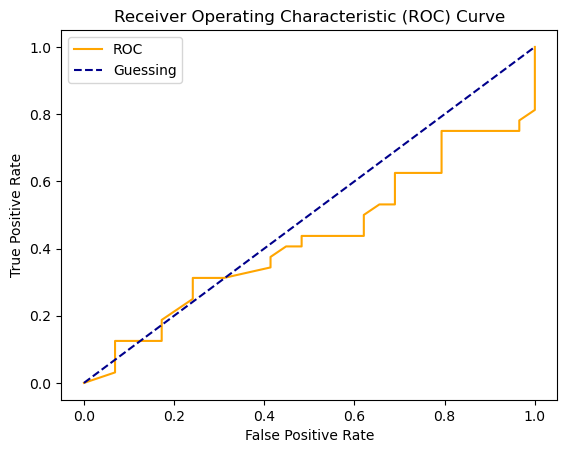

In [183]:
import matplotlib.pyplot as plt

def plot_roc_curve(fpr, tpr):
    """
    Plots a ROC Curve given the value of false positive rate (fpr)
    and true positive rate (tpr) of model.
    """
    # Plot Roc Curve
    plt.plot(fpr, tpr, color="orange", label="ROC")
    # Plot line with no predictive power(baseline)
    plt.plot([0,1], [0,1], color="darkblue", linestyle="--", label="Guessing")

    # Customize the plot
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Receiver Operating Characteristic (ROC) Curve")
    plt.legend()
    plt.show()

plot_roc_curve(fpr, tpr)

In [184]:
from sklearn.metrics import roc_auc_score
roc_auc_score(Y_test, Y_probs_positive)

0.42995689655172414

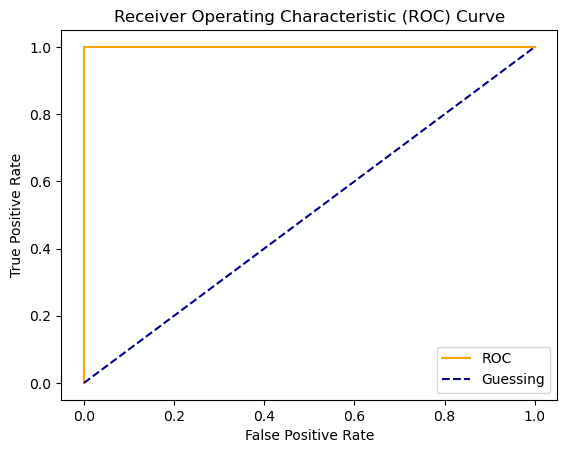

In [185]:
# Plot perfect ROC Curve and AUC Score
fpr, tpr, thresholds = roc_curve(Y_test, Y_test)
plot_roc_curve(fpr, tpr)

In [ ]:
# Perfect AUC Score
roc_auc_score(Y_test)